### QisKit Simulator

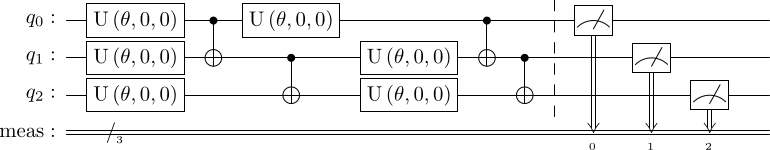

In [1]:
import numpy as np
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

angle = Parameter("\\theta")  # undefined number

# Create and optimize circuit once
qc = QuantumCircuit(3)
qc.ry(angle, [0,1,2])
qc.cx(0,1)
qc.cx(1,2)
qc.ry(angle, [0,1,2])
qc.cx(0,1)
qc.cx(1,2)
qc.measure_all()
qc = generate_preset_pass_manager(
    optimization_level=3, basis_gates=["u", "cx"]
).run(qc)

qc.draw('latex')

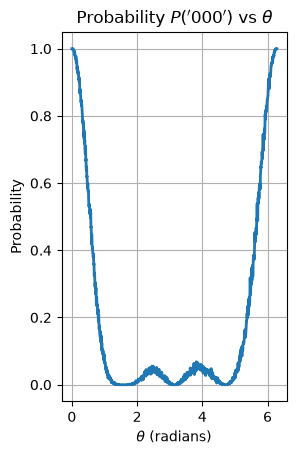

In [3]:
sampler = Sampler()  # Instantiate outside the loop for efficiency
angle_vals = np.linspace(0, 2 * np.pi, 1000)
p000_list = []

for val in angle_vals:
    # Run sampler with the parameterized angle value
    job = sampler.run([(qc, {angle: val})])
    result = job.result()

    counts = result[0].data.meas.get_counts()
    total_shots = sum(counts.values())

    # Get count for '000' safely (returns 0 if not measured)
    count_000 = counts.get("000", 0)
    p000 = count_000 / total_shots
    p000_list.append(p000)
    
# Plot P('000')
plt.subplot(1, 2, 1)
plt.plot(angle_vals, p000_list, label=r"$P('000')$", color="tab:blue", linewidth=2)
plt.xlabel(r"$\theta$ (radians)")
plt.ylabel("Probability")
plt.title(r"Probability $P('000')$ vs $\theta$")
plt.grid(True)